In [32]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq #ft=fourier transform
#uso algoritmo fast fourier transform=fft
#algoritmo è implementato in fftw=fast fourier transform in wisdom
#rfftn-->n = griglia generica, output non è Nk^2 (come in rfft2), ma Nk/2
#rfftn-->r = passo dei reali

In [33]:
#f(-k)=-f(k)
#bisogna associare ad ogni punto griglia(nello spazio di fourier) le sue coordinate (nello spazio fisico)
#box size in mpc/h
L=1000 
#number of grid points
N=100000
X,Y,Z=np.random.rand(3,N)*L

In [34]:
#create the grid (3d histogram)
n=64 #meglio multiplo di 2 per fft
grid,edges=np.histogramdd((X,Y,Z),bins=(n,n,n),range=((0,L),(0,L),(0,L))) #questa è l'interpol piu semplice, il primo metodo degli appunti , è detta NGP

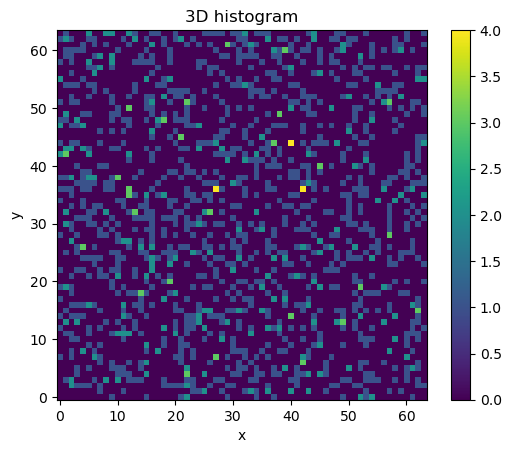

In [35]:
plt.imshow(grid[:,:,0],origin='lower')
plt.colorbar()
plt.title('3D histogram')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [36]:
rho_mean=N/(L**3) #densità media di part che cascano in ogni cella #N=number of particles
cell_volume=(L/n)**3 #volume di ogni cella
#compute density contrast
delta=(grid-rho_mean*cell_volume)/(rho_mean*cell_volume)

In [37]:
np.mean(delta),rho_mean #-->circa 0, come pensavamo

(np.float64(-1.0625181290357943e-17), 0.0001)

In [38]:
#compute the FFT of the contrast density field
delta_k=rfftn(delta) 


In [39]:
delta_k.shape #-->64x64x32, 3d fft, 2d fft in 3d
#conserva dimensioni e ultima è dimezzata perchè non si deve salvare i complessi coniug dei k negativi perchè sono uguali : f(-k)=-f(k)

(64, 64, 33)

In [40]:
#vedi numpy.fft.fftfreq su google,con d=L/(2*np.pi)=sample spacing=inverso del sample rate
kF=2*np.pi/L #kF=frequenza fondamentale, la piu bassa che si puo avere
kx=fftfreq(n,d=1/n)*kF #frequenze in x
ky=fftfreq(n,d=1/n)*kF
#kz=fftfreq(n,d=1/n)*kF #frequenze in z-->vengono solo i postivi ovviamente, per quello detto nella cella di sopra della shape
kz = rfftfreq(n, d=1/n) * kF
#ho ancora tre array separati
KX,KY,KZ=np.meshgrid(kx,ky,kz)#associo ad ogni punto griglia il valore di k
KK=np.sqrt(KX**2+KY**2+KZ**2)

In [41]:
pk_grid=delta_k*delta_k.conjugate() 

In [42]:
kN=np.sqrt(2*np.pi)*n/L

kF,kN
n_bins_k=100
k_edges=np.linspace(kF,kN,n_bins_k+1)
pk_array=np.zeros(n_bins_k)
for i in range(n_bins_k):
    k_min=k_edges[i]
    k_max=k_edges[i+1]
    mask=(KK.flatten()>=k_min)&(KK.flatten()<k_max)
    pk=np.mean(pk_grid.flatten()[mask]).real
    pk_array[i]=pk
    #print(k_min,k_max,pk)


/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/maddaba/anaconda3/envs/acc-env/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


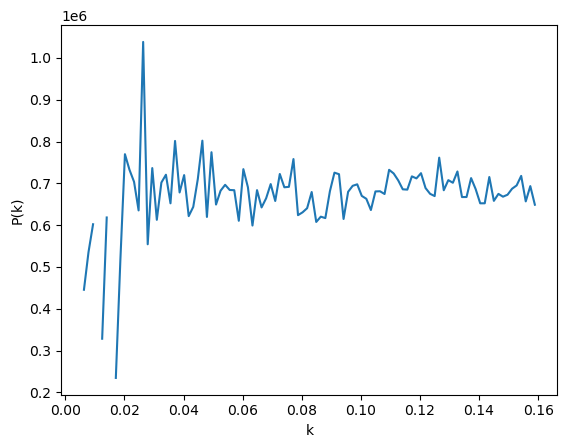

In [43]:
plt.plot(k_edges[:-1],pk_array)
plt.xlabel('k')
plt.ylabel('P(k)')
plt.show()

ho sempre segnale intrinseco e poi shotnoise, legato a densità del campione-->devo fare sample in modo che il suo segnale vinca su suo shot noise; come lo faccio? 1) survey molto densa,2)aumento il clustering del campione